In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("detections_cleaned.csv")


In [ ]:
df["frame_group"] = (df["frame"] != df["frame"].shift()).cumsum()


In [ ]:
situation_features = []

for fg, g in df.groupby("frame_group"):
    # counts
    total_detections = len(g)

    # spatial means
    mean_x = g["x"].mean()
    mean_y = g["y"].mean()

    # spatial variance
    var_x = g["x"].var()
    var_y = g["y"].var()

    # bounding box area
    area = g["width"] * g["height"]
    mean_bbox_area = area.mean()

    # centroids
    cx = g["x"] + g["width"] / 2
    cy = g["y"] + g["height"] / 2
    centroid_x = cx.mean()
    centroid_y = cy.mean()

    # spatial dispersion
    dist = np.sqrt((cx - centroid_x)**2 + (cy - centroid_y)**2)
    mean_spatial_dispersion = dist.mean()

    # confidence
    mean_confidence = g["confidence"].mean()

    situation_features.append({
        "situation_id": fg,
        "total_detections": total_detections,
        "mean_x": mean_x,
        "mean_y": mean_y,
        "var_x": var_x,
        "var_y": var_y,
        "mean_bbox_area": mean_bbox_area,
        "centroid_x": centroid_x,
        "centroid_y": centroid_y,
        "mean_spatial_dispersion": mean_spatial_dispersion,
        "mean_confidence": mean_confidence
    })


In [ ]:
situations_df = pd.DataFrame(situation_features)
situations_df.head()


,situation_id,total_detections,mean_x,mean_y,var_x,var_y,mean_bbox_area,centroid_x,centroid_y,mean_spatial_dispersion,mean_confidence
0,1,4,220.50,135.50,7079.00,2497.000000,860.25,236.875,148.375,79.907040,1.0
1,2,4,220.50,136.50,7079.00,2497.000000,860.25,236.875,149.375,79.907040,1.0
2,3,4,220.50,137.50,7079.00,2497.000000,860.25,236.875,150.375,79.907040,1.0
3,4,4,220.50,138.25,7079.00,2462.916667,860.25,236.875,151.125,79.666557,1.0
4,5,4,220.25,139.25,7148.25,2462.916667,860.25,236.625,152.125,79.918869,1.0


In [ ]:
output_path = "frame_group_situations.csv"
situations_df.to_csv(output_path, index=False)

print(f"Saved to {output_path}")


Saved to frame_group_situations.csv


In [ ]:
df_filtered = situations_df[situations_df['total_detections'] > 1].copy()
print("Filtered shape:", df_filtered.shape)
print("Rows removed:", situations_df.shape[0] - df_filtered.shape[0])



Filtered shape: (6592, 11)
Rows removed: 252


In [ ]:
for col in df_filtered.columns:
  print(col)

situation_id
total_detections
mean_x
mean_y
var_x
var_y
mean_bbox_area
centroid_x
centroid_y
mean_spatial_dispersion
mean_confidence


In [ ]:
df_filtered = df_filtered.drop(columns=['situation_id', 'mean_confidence'])
print("Filtered shape:", df_filtered.shape)

Filtered shape: (6592, 9)


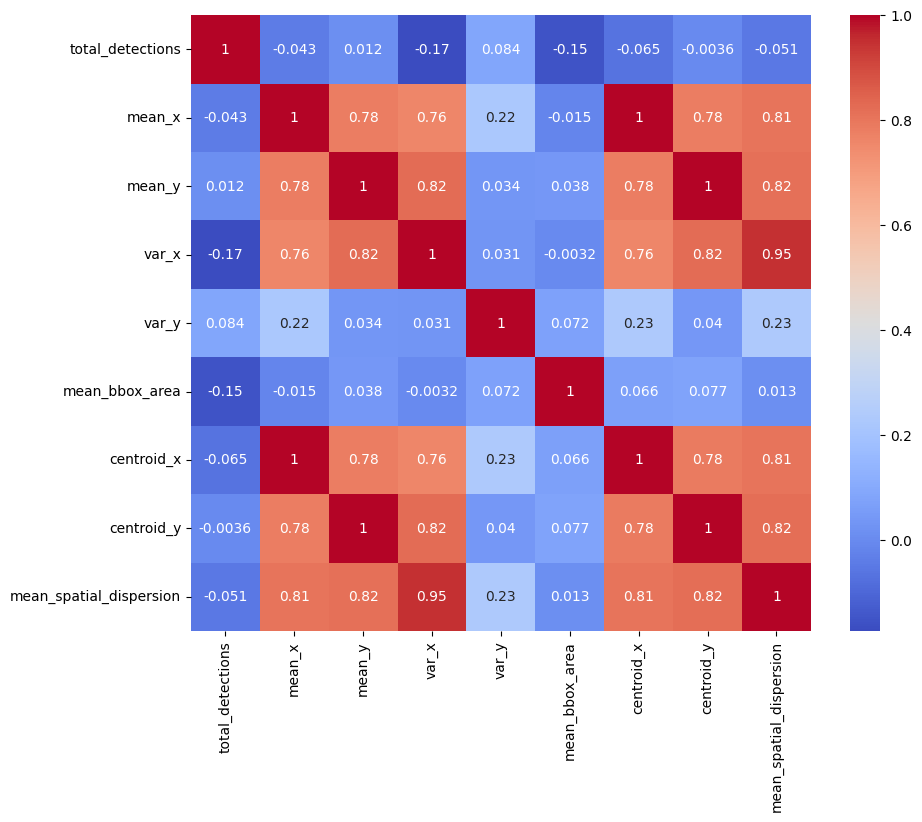

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_filtered.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
df_filtered = df_filtered.drop(columns=['centroid_x', 'centroid_y'])
print(df_filtered.shape)

(6592, 7)


In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df_filtered,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (5273, 7)
Test shape: (1319, 7)


In [ ]:
train = df_filtered.copy()
log_features = ['var_x', 'var_y', 'mean_bbox_area']
for col in log_features:
  if col in train.columns:
    train[col] = np.log1p(train[col])
    #test[col] = np.log1p(test[col])

In [ ]:
train.head()
#test.head()


,total_detections,mean_x,mean_y,var_x,var_y,mean_bbox_area,mean_spatial_dispersion
0,4,220.50,135.50,8.865029,7.823246,6.758385,79.907040
1,4,220.50,136.50,8.865029,7.823246,6.758385,79.907040
2,4,220.50,137.50,8.865029,7.823246,6.758385,79.907040
3,4,220.50,138.25,8.865029,7.809508,6.758385,79.666557
4,4,220.25,139.25,8.874763,7.809508,6.758385,79.918869


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train)
#test_scaled = scaler.transform(test)

In [ ]:
print(train_scaled[:10])

[[-0.68522467 -1.06299622 -0.7586931  -1.18702566 -0.65490643  0.26718234
  -1.16705713]
 [-0.68522467 -1.06299622 -0.7529173  -1.18702566 -0.65490643  0.26718234
  -1.16705713]
 [-0.68522467 -1.06299622 -0.7471415  -1.18702566 -0.65490643  0.26718234
  -1.16705713]
 [-0.68522467 -1.06299622 -0.74280964 -1.18702566 -0.66643483  0.26718234
  -1.16921753]
 [-0.68522467 -1.06396622 -0.73703384 -1.18008221 -0.66643483  0.26718234
  -1.16695087]
 [-0.68522467 -1.06396622 -0.73414594 -1.18008221 -0.6703036   0.26718234
  -1.16711639]
 [-0.68522467 -1.06299622 -0.72981409 -1.17325511 -0.68198915  0.26718234
  -1.16706739]
 [-0.68522467 -1.06299622 -0.72403829 -1.17325511 -0.68198915  0.28353361
  -1.16814096]
 [-0.68522467 -1.06396622 -0.72403829 -1.17346103 -0.68198915  0.27438701
  -1.16825431]
 [-0.68522467 -1.06396622 -0.72259433 -1.17346103 -0.68016965  0.2934425
  -1.16814386]]


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
train_pca = pca.fit_transform(train_scaled)
#test_pca = pca.transform(test_scaled)

In [ ]:
print(train_scaled.shape)

(6592, 7)


In [ ]:
pca_columns = [f"PC{i+1}" for i in range(5)]

train_pca_df = pd.DataFrame(train_pca, columns=pca_columns)
#test_pca_df = pd.DataFrame(test_pca, columns=pca_columns)


#  EXPORT
train_pca_df.to_csv("data_pca.csv", index=False)
#test_pca_df.to_csv("test_pca.csv", index=False)

print("PCA files exported successfully.")

PCA files exported successfully.


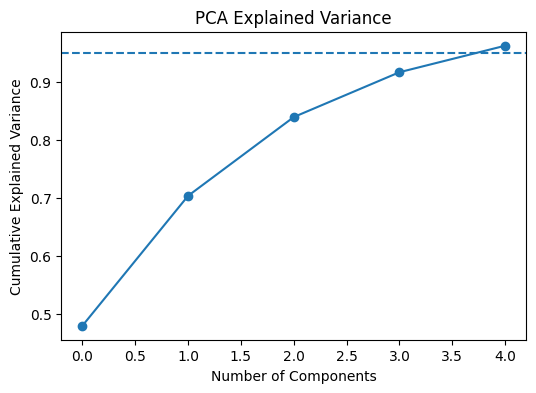

In [ ]:
import numpy as np

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(cum_var, marker='o')
plt.axhline(0.95, linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()


Detected anomalies: 66


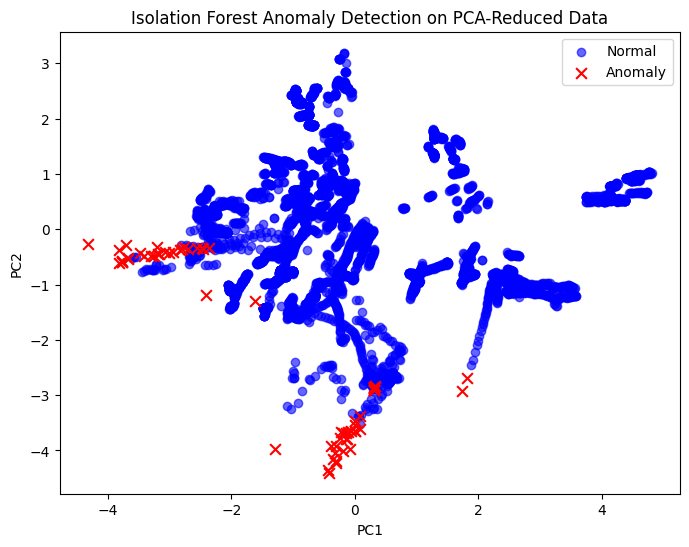

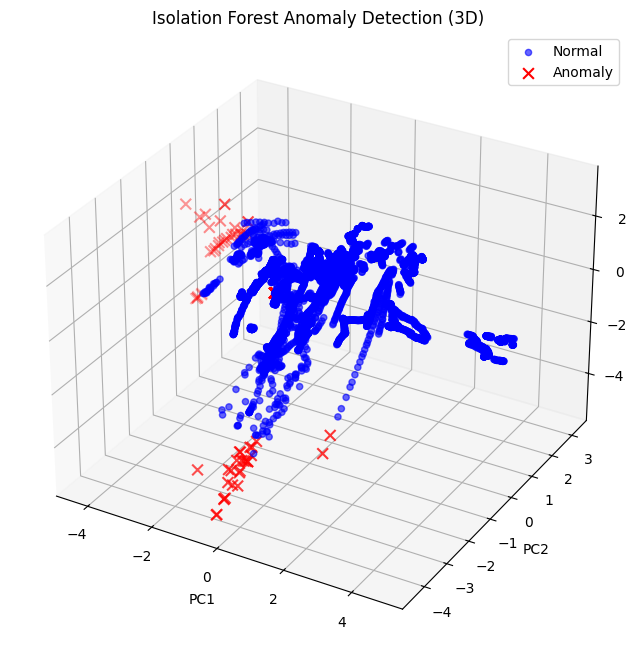

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import pandas as pd

# PCA-transformed data
X = train_pca  # shape (6592, 5)

# Isolation Forest for anomaly detection
iso_forest = IsolationForest(
    contamination=0.01,
    n_estimators=1200,
    max_features=0.85,
    max_samples="auto",
    random_state=42
)
labels = iso_forest.fit_predict(X)

# Isolation Forest labels: 1 = normal, -1 = anomaly
df_iso = pd.DataFrame(X, columns=[f'PC{i+1}' for i in range(X.shape[1])])
df_iso['Anomaly'] = labels

# Count anomalies
n_anomalies = (labels == -1).sum()
print(f"Detected anomalies: {n_anomalies}")

# 2D Visualization (PC1 vs PC2)
plt.figure(figsize=(8,6))
plt.scatter(df_iso[df_iso['Anomaly']==1]['PC1'], df_iso[df_iso['Anomaly']==1]['PC2'],
            c='blue', label='Normal', alpha=0.6)
plt.scatter(df_iso[df_iso['Anomaly']==-1]['PC1'], df_iso[df_iso['Anomaly']==-1]['PC2'],
            c='red', label='Anomaly', marker='x', s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Isolation Forest Anomaly Detection on PCA-Reduced Data')
plt.legend()
plt.show()


# 3D Visualization (PC1, PC2, PC3)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_iso[df_iso['Anomaly']==1]['PC1'],
           df_iso[df_iso['Anomaly']==1]['PC2'],
           df_iso[df_iso['Anomaly']==1]['PC3'],
           c='blue', alpha=0.6, label='Normal')
ax.scatter(df_iso[df_iso['Anomaly']==-1]['PC1'],
           df_iso[df_iso['Anomaly']==-1]['PC2'],
           df_iso[df_iso['Anomaly']==-1]['PC3'],
           c='red', marker='x', s=60, label='Anomaly')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Isolation Forest Anomaly Detection (3D)')
ax.legend()
plt.show()


Detected anomalies (DBSCAN): 43


/tmp/ipython-input-333/1543972178.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels))


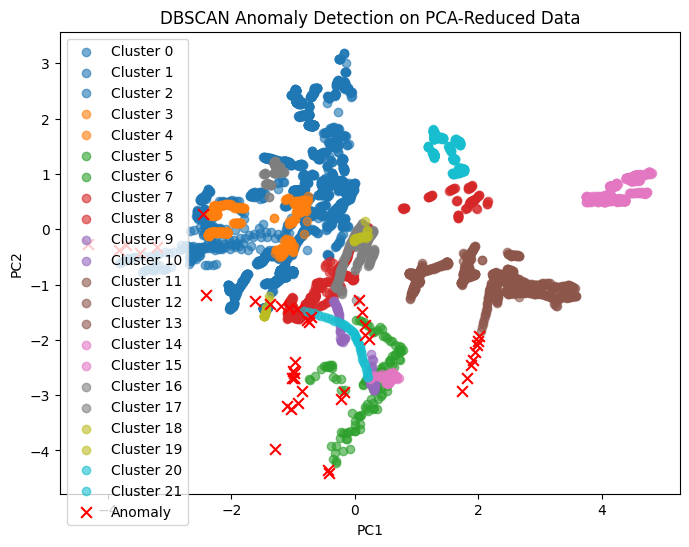

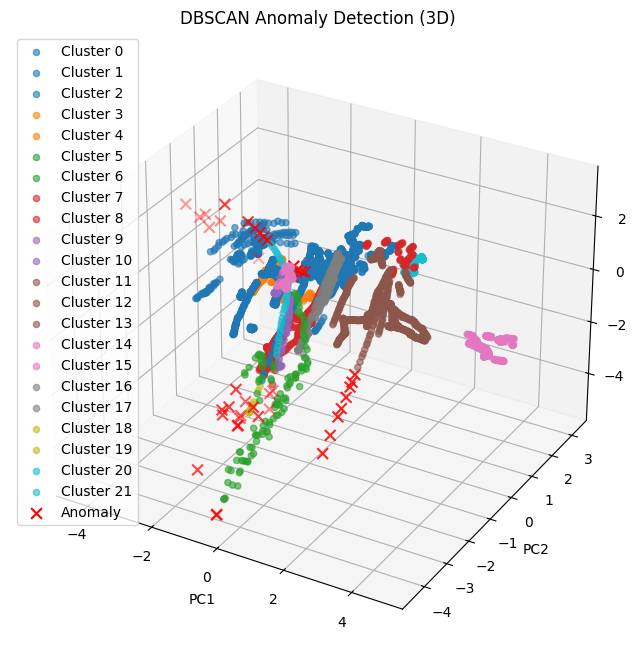

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import pandas as pd

# PCA-transformed data
X = train_pca  # shape (6592, 5)

# DBSCAN for anomaly detection
dbscan = DBSCAN(eps=0.65, min_samples=10)  # tune eps/min_samples as needed
labels = dbscan.fit_predict(X)

# DBSCAN labels: -1 = anomaly/noise
df_db = pd.DataFrame(X, columns=[f'PC{i+1}' for i in range(X.shape[1])])
df_db['Anomaly'] = labels

# Count anomalies
n_anomalies = (labels == -1).sum()
print(f"Detected anomalies (DBSCAN): {n_anomalies}")

# 2D Visualization (PC1 vs PC2)
plt.figure(figsize=(8,6))
unique_labels = set(labels)
colors = plt.cm.get_cmap('tab10', len(unique_labels))

for k in unique_labels:
    cluster_mask = (labels == k)
    xy = X[cluster_mask]
    if k == -1:
        plt.scatter(xy[:,0], xy[:,1], c='red', marker='x', label='Anomaly', s=60)
    else:
        plt.scatter(xy[:,0], xy[:,1], c=[colors(k)], label=f'Cluster {k}', alpha=0.6)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN Anomaly Detection on PCA-Reduced Data')
plt.legend()
plt.show()

# 3D Visualization (PC1, PC2, PC3)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
for k in unique_labels:
    cluster_mask = (labels == k)
    xyz = X[cluster_mask]
    if k == -1:
        ax.scatter(xyz[:,0], xyz[:,1], xyz[:,2], c='red', marker='x', s=60, label='Anomaly')
    else:
        ax.scatter(xyz[:,0], xyz[:,1], xyz[:,2], c=[colors(k)], alpha=0.6, label=f'Cluster {k}')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('DBSCAN Anomaly Detection (3D)')
ax.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN

X = train_pca

# ---- Isolation Forest ----
iso_forest = IsolationForest(
    contamination=0.01,
    n_estimators=1200,
    max_features=0.85,
    max_samples="auto",
    random_state=42
)
iso_labels = iso_forest.fit_predict(X)   # 1 = normal, -1 = anomaly

# ---- DBSCAN ----
dbscan = DBSCAN(eps=0.65, min_samples=10)
db_labels = dbscan.fit_predict(X)        # -1 = anomaly

In [ ]:
iso_anomaly_idx = np.where(iso_labels == -1)[0]

In [ ]:
def sample_anomalies(indices, percent, random_state=42):
    rng = np.random.default_rng(random_state)
    k = int(len(indices) * percent)
    return rng.choice(indices, size=k, replace=False)

# Example: take 30% of Isolation Forest anomalies
sampled_iso_anomalies = sample_anomalies(
    iso_anomaly_idx,
    percent=0.40,
    random_state=42
)

In [ ]:
# Copy DBSCAN labels so we don't destroy originals
db_labels_fused = db_labels.copy()

# Force sampled Isolation Forest anomalies into DBSCAN result
for idx in sampled_iso_anomalies:
    if db_labels_fused[idx] != -1:
        db_labels_fused[idx] = -1

In [ ]:
iso_anomaly = (iso_labels == -1)
db_anomaly  = (db_labels_fused == -1)

In [ ]:
overlap = iso_anomaly & db_anomaly

n_iso = iso_anomaly.sum()
n_db = db_anomaly.sum()
n_overlap = overlap.sum()


print(f"% of ISO anomalies also in DBSCAN: {n_overlap / n_iso:.2%}")
print(f"% of DBSCAN anomalies also in ISO: {n_overlap / n_db:.2%}")

% of ISO anomalies also in DBSCAN: 50.00%
% of DBSCAN anomalies also in ISO: 51.56%


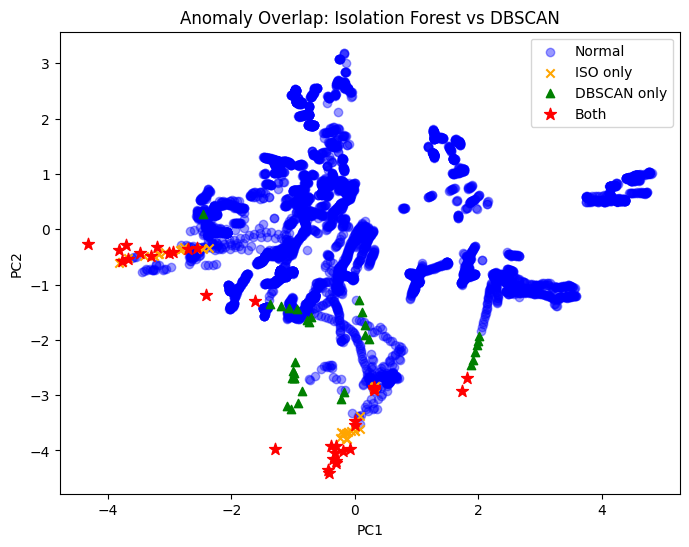

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

both = overlap
iso_only = iso_anomaly & ~db_anomaly
db_only = db_anomaly & ~iso_anomaly
normal = ~(iso_anomaly | db_anomaly)

plt.scatter(X[normal,0], X[normal,1], c='blue', alpha=0.4, label='Normal')
plt.scatter(X[iso_only,0], X[iso_only,1], c='orange', marker='x', label='ISO only')
plt.scatter(X[db_only,0], X[db_only,1], c='green', marker='^', label='DBSCAN only')
plt.scatter(X[both,0], X[both,1], c='red', marker='*', s=80, label='Both')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Anomaly Overlap: Isolation Forest vs DBSCAN')
plt.legend()
plt.show()